In [2]:
%load_ext autoreload
%autoreload 2

import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from multiprocessing import Pool
import seaborn as sns


In [3]:
# Check for the presence of the protein regardless of the rna expression?
# https://www.proteinatlas.org/ENSG00000089041-P2RX7/tissue#rna_expression
id_vars = ["Ensembl", "gene_name", "Gene description"]

cpm_data = (
    pd.read_csv("data/cpm.csv", sep="\t")
    .melt(id_vars=id_vars)
    .assign(variable=lambda x: x.variable.str.split(".").str[0])
    .assign(value=lambda x: x["value"].astype(str).str.replace(",", ".").astype(float))
    .query('variable.str.contains("3D", regex=True)')
)

raw_count_data = (
    pd.read_csv("data/rawcount.csv", sep="\t")
    .melt(id_vars=id_vars)
    .assign(variable=lambda x: x.variable.str.split(".").str[0])
    .assign(value=lambda x: x["value"].astype(str).str.replace(",", ".").astype(float))
    .query('variable.str.contains("3D", regex=True)')
)

In [11]:
grouped = cpm_data.groupby('gene_name')['value']

std = grouped.std().reset_index().assign(value = lambda x: x['value'].apply(lambda y: f'{y:.2f}'))
grouped.mean().reset_index().assign(value = lambda x: x['value'].apply(lambda y: f'{y:.2f}') + ' ± ' + std['value'])

,gene_name,value
0,Adam17,172.97 ± 10.59
1,Adora1,106.84 ± 5.88
2,Agtr1a,0.13 ± 0.00
3,F2r,126.88 ± 5.45
4,F2rl3,0.25 ± 0.09
5,Gmnn,79.07 ± 7.03
6,Hmgcr,154.00 ± 17.32
7,Mitf,4.91 ± 1.19
8,Nr3c2,6.19 ± 0.53
9,P2rx7,0.47 ± 0.14


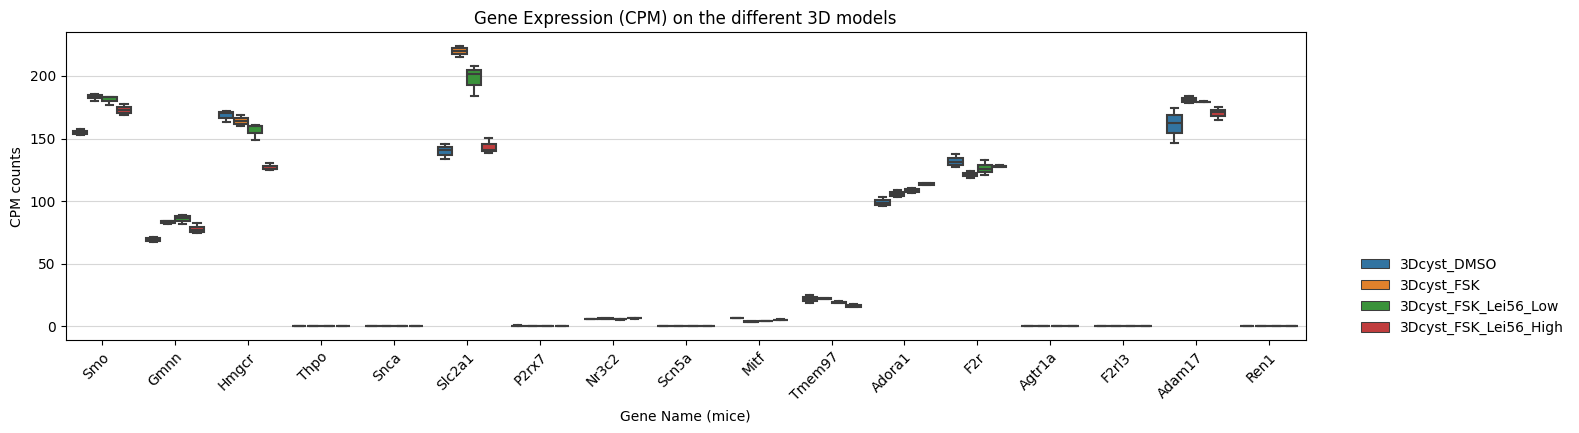

In [3]:
fig, ax = plt.subplots(figsize=(16, 4))
sns.boxplot(data=cpm_data, x="gene_name", y="value", hue="variable")
ax.set_xticklabels(
    ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor"
)
ax.legend(bbox_to_anchor=(1.04, 0), loc="lower left", borderaxespad=0, frameon=False)
ax.grid(axis="y", alpha=0.5)
ax.set_axisbelow(True)
ax.set_title("Gene Expression (CPM) on the different 3D models")
ax.set_xlabel("Gene Name (mice)")
ax.set_ylabel("CPM counts")
fig.savefig("figures/cpm.png", bbox_inches="tight", dpi=300, facecolor="w")

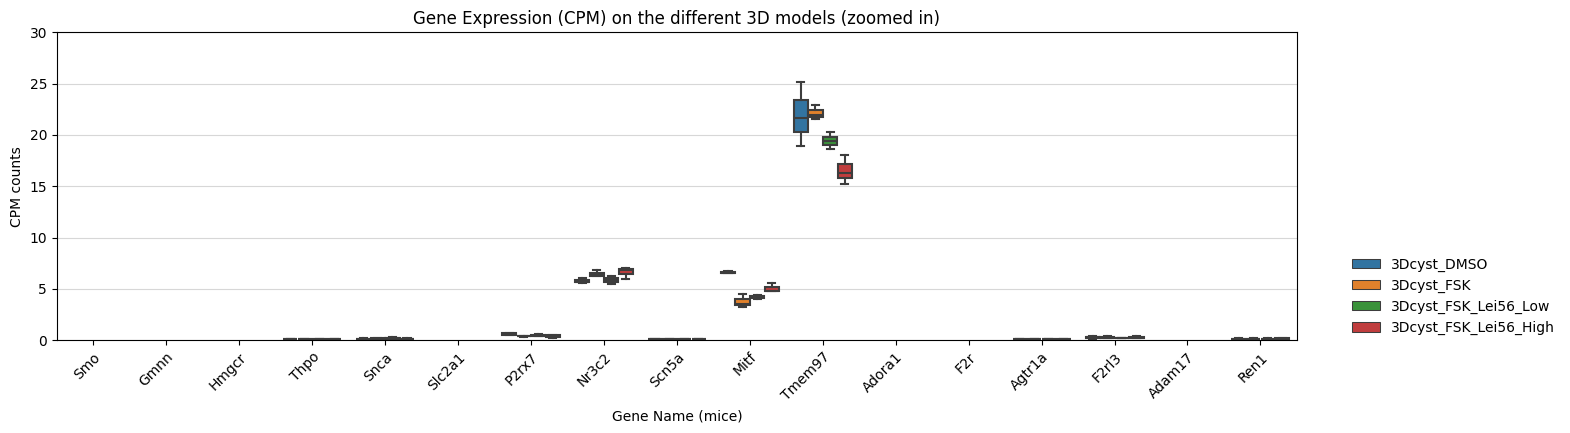

In [4]:
fig, ax = plt.subplots(figsize=(16, 4))
sns.boxplot(data=cpm_data, x="gene_name", y="value", hue="variable")
ax.set_xticklabels(
    ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor"
)
ax.legend(bbox_to_anchor=(1.04, 0), loc="lower left", borderaxespad=0, frameon=False)
ax.grid(axis="y", alpha=0.5)
ax.set_axisbelow(True)
ax.set_title("Gene Expression (CPM) on the different 3D models (zoomed in)")
ax.set_xlabel("Gene Name (mice)")
ax.set_ylabel("CPM counts")
ax.set_ylim(0, 30)
fig.savefig("figures/cpm_zoomed.png", bbox_inches="tight", dpi=300, facecolor="w")

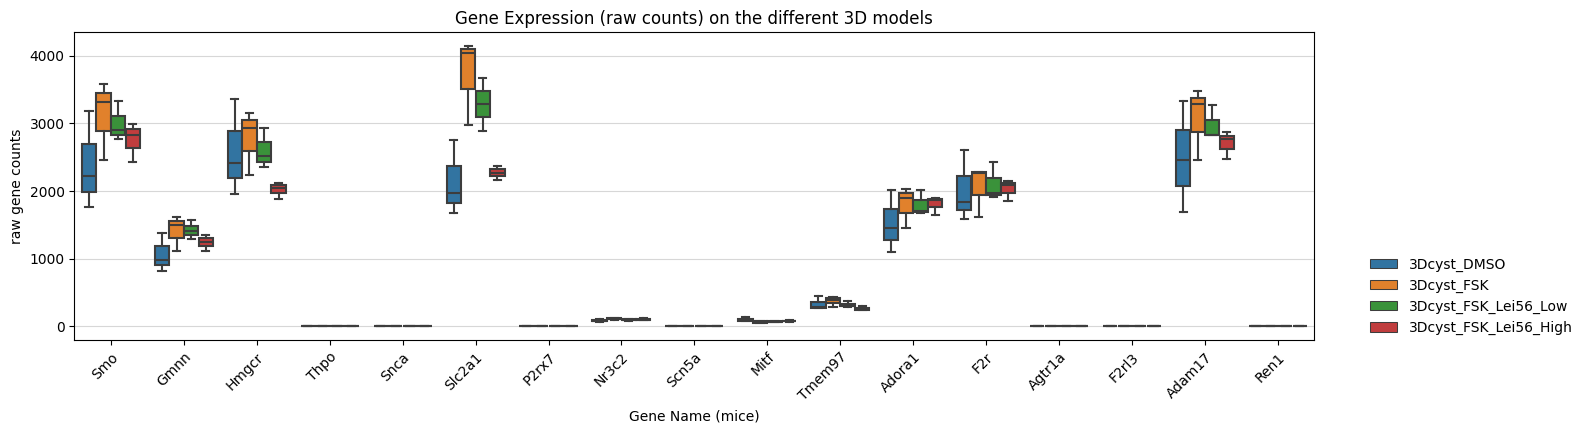

In [5]:
fig, ax = plt.subplots(figsize=(16, 4))
sns.boxplot(data=raw_count_data, x="gene_name", y="value", hue="variable")
ax.set_xticklabels(
    ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor"
)
ax.legend(bbox_to_anchor=(1.04, 0), loc="lower left", borderaxespad=0, frameon=False)
ax.grid(axis="y", alpha=0.5)
ax.set_axisbelow(True)
ax.set_title("Gene Expression (raw counts) on the different 3D models")
ax.set_xlabel("Gene Name (mice)")
ax.set_ylabel("raw gene counts")
fig.savefig("figures/raw_counts.png", bbox_inches="tight", dpi=300, facecolor="w")

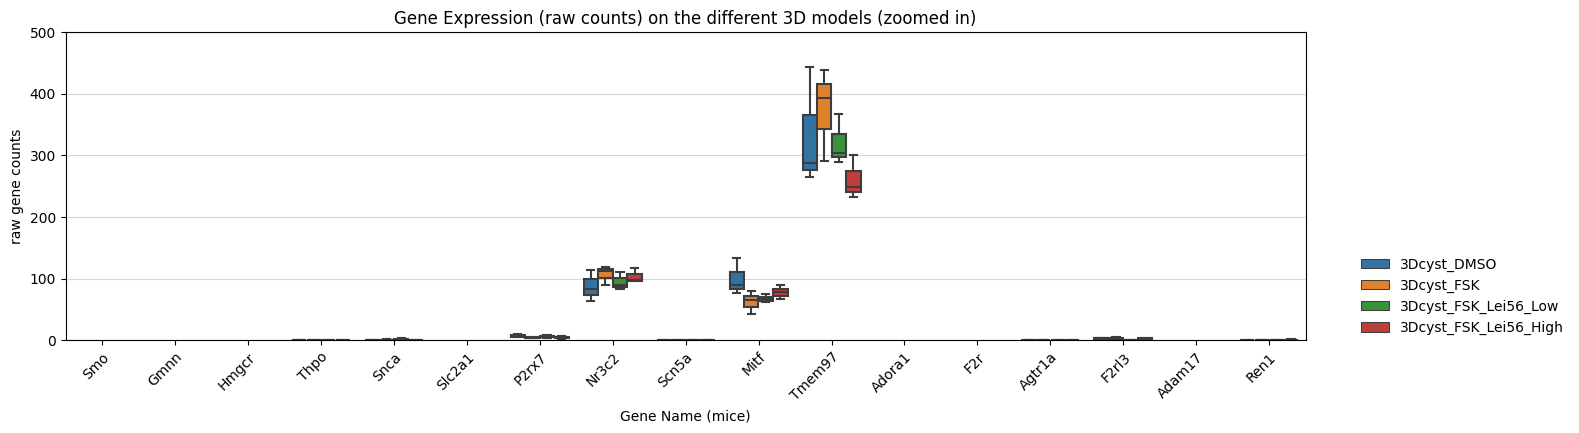

In [6]:
fig, ax = plt.subplots(figsize=(16, 4))
sns.boxplot(data=raw_count_data, x="gene_name", y="value", hue="variable")
ax.set_xticklabels(
    ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor"
)
ax.legend(bbox_to_anchor=(1.04, 0), loc="lower left", borderaxespad=0, frameon=False)
ax.grid(axis="y", alpha=0.5)
ax.set_axisbelow(True)
ax.set_title("Gene Expression (raw counts) on the different 3D models (zoomed in)")
ax.set_xlabel("Gene Name (mice)")
ax.set_ylabel("raw gene counts")
ax.set_ylim(0, 500)
fig.savefig(
    "figures/raw_counts_zoomed.png", bbox_inches="tight", dpi=300, facecolor="w"
)